# Spaceship Titanic — Perbandingan 7 Model Machine Learning

Notebook ini dirancang sebagai pipeline eksperimen yang membandingkan tujuh pendekatan klasifikasi secara sistematis pada dataset Spaceship Titanic dari Kaggle. Setiap model dilatih menggunakan data yang sama, dievaluasi pada set validasi yang sama, dan menghasilkan file prediksi tersendiri untuk keperluan submission.

Tujuh model yang dibandingkan adalah XGBoost, LightGBM, Random Forest, Extra Trees, CatBoost, Neural Network sederhana berbasis PyTorch, dan Stacked Ensemble. Khusus untuk Stacked Ensemble, model ini dibangun di atas lima model pertama sebagai base learner, dengan Logistic Regression sebagai meta-learner.

Evaluasi dilakukan menggunakan empat metrik: accuracy, precision, recall, dan F1 score, yang divisualisasikan dalam satu bar chart terintegrasi untuk memudahkan perbandingan.

## 1. Instalasi dan Persiapan Library

Beberapa library memerlukan instalasi tambahan yang tidak tersedia secara default di Google Colab, yaitu LightGBM, CatBoost, XGBoost, dan Optuna untuk tuning. PyTorch sudah tersedia di Colab sehingga tidak perlu diinstal ulang.

In [ ]:
!pip install lightgbm catboost xgboost optuna --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from scipy.optimize import minimize

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Semua library berhasil diimpor.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.1 MB/s eta 0:00:00
Semua library berhasil diimpor.


## 2. Memuat Data

Dataset terdiri dari dua file utama: train.csv yang berisi data berlabel untuk pelatihan, dan test.csv yang berisi data tanpa label untuk prediksi akhir. Pastikan kedua file sudah diunggah ke sesi Colab sebelum menjalankan sel ini.

Informasi group dari PassengerId disimpan terpisah sejak awal karena akan digunakan dalam tahap feature engineering dan post-processing.

In [ ]:
# Uncomment untuk upload manual:
# from google.colab import files
# files.upload()

train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')
test_ids  = test_raw['PassengerId'].copy()

train_groups = train_raw['PassengerId'].str.split('_').str[0].astype(int)
test_groups  = test_raw['PassengerId'].str.split('_').str[0].astype(int)

print(f'Train : {train_raw.shape[0]} baris, {train_raw.shape[1]} kolom')
print(f'Test  : {test_raw.shape[0]} baris, {test_raw.shape[1]} kolom')
print(f'Target: {train_raw["Transported"].value_counts().to_dict()}')
train_raw.head(3)

Train : 8693 baris, 14 kolom
Test  : 4277 baris, 13 kolom
Target: {True: 4378, False: 4315}


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


## 3. Exploratory Data Analysis

Sebelum masuk ke tahap pemodelan, perlu dipahami terlebih dahulu karakteristik dataset ini. EDA yang dilakukan mencakup pemeriksaan missing values, distribusi target, statistik deskriptif fitur numerik, dan pola distribusi antar variabel kategorik terhadap label target.

Beberapa temuan kunci dari EDA ini akan memengaruhi keputusan desain pada tahap feature engineering, terutama bagaimana menangani nilai yang hilang secara logis berdasarkan hubungan antar variabel.

In [ ]:
print('=== Distribusi Target ===')
vc = train_raw['Transported'].value_counts(normalize=True)
print(f'True  : {vc[True]:.3f} ({train_raw["Transported"].sum()} sampel)')
print(f'False : {vc[False]:.3f} ({(~train_raw["Transported"]).sum()} sampel)')
print('Target sangat seimbang, tidak diperlukan teknik oversampling.\n')

print('=== Missing Values (Train) ===')
miss = train_raw.isnull().sum()
miss_pct = (miss / len(train_raw) * 100).round(2)
miss_df = pd.DataFrame({'Jumlah': miss, 'Persentase (%)': miss_pct})
print(miss_df[miss_df['Jumlah'] > 0].to_string())

=== Distribusi Target ===
True  : 0.504 (4378 sampel)
False : 0.496 (4315 sampel)
Target sangat seimbang, tidak diperlukan teknik oversampling.

=== Missing Values (Train) ===
              Jumlah  Persentase (%)
HomePlanet       201            2.31
CryoSleep        217            2.50
Cabin            199            2.29
Destination      182            2.09
Age              179            2.06
VIP              203            2.34
RoomService      181            2.08
FoodCourt        183            2.11
ShoppingMall     208            2.39
Spa              183            2.11
VRDeck           188            2.16
Name             200            2.30


In [ ]:
SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
CAT_COLS   = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

print('=== Statistik Deskriptif Fitur Numerik ===')
print(train_raw[['Age'] + SPEND_COLS].describe().round(2).to_string())

=== Statistik Deskriptif Fitur Numerik ===
           Age  RoomService  FoodCourt  ShoppingMall       Spa    VRDeck
count  8514.00      8512.00    8510.00       8485.00   8510.00   8505.00
mean     28.83       224.69     458.08        173.73    311.14    304.85
std      14.49       666.72    1611.49        604.70   1136.71   1145.72
min       0.00         0.00       0.00          0.00      0.00      0.00
25%      19.00         0.00       0.00          0.00      0.00      0.00
50%      27.00         0.00       0.00          0.00      0.00      0.00
75%      38.00        47.00      76.00         27.00     59.00     46.00
max      79.00     14327.00   29813.00      23492.00  22408.00  24133.00


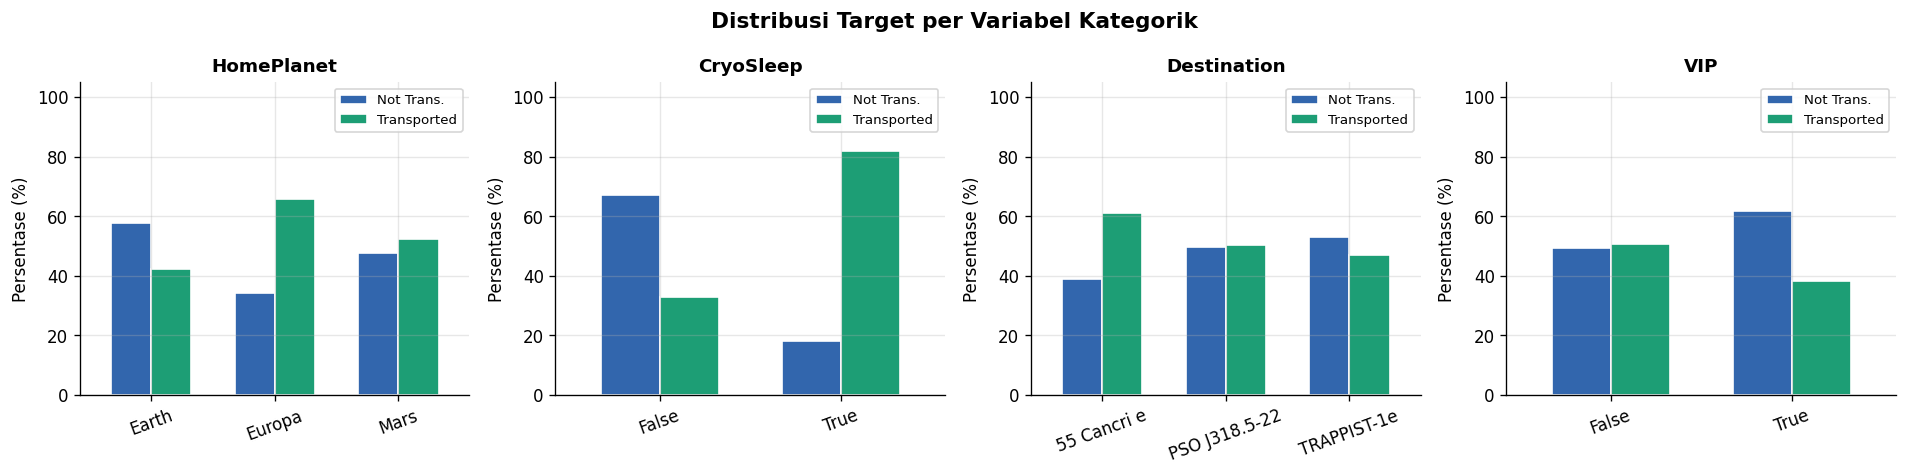

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
palette = {'False': '#3266ad', 'True': '#1d9e75'}

for ax, col in zip(axes, CAT_COLS):
    ct = train_raw.groupby(col)['Transported'].value_counts(normalize=True).unstack() * 100
    ct.rename(columns={False:'Not Trans.', True:'Transported'}, inplace=True)
    ct[['Not Trans.', 'Transported']].plot(kind='bar', ax=ax,
        color=['#3266ad','#1d9e75'], edgecolor='white', width=0.65)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel('Persentase (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    ax.set_ylim(0, 105)

plt.suptitle('Distribusi Target per Variabel Kategorik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight')
plt.show()

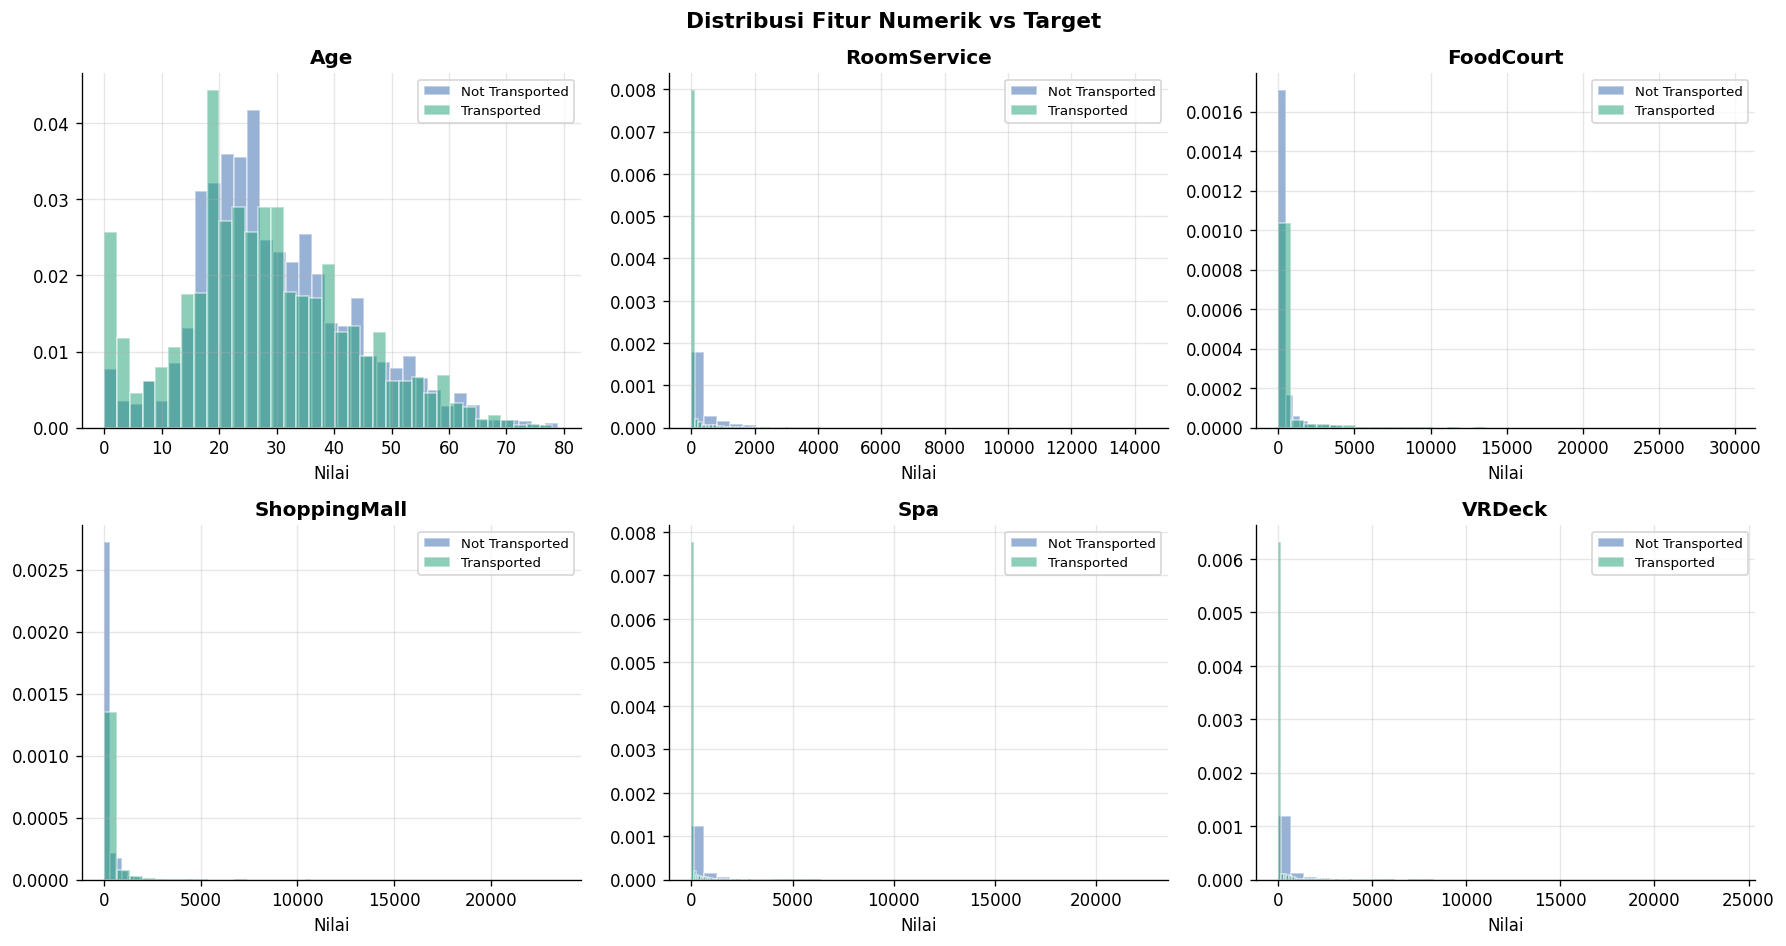

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(['Age'] + SPEND_COLS):
    ax = axes[i]
    for transported, color, label in [
        (False, '#3266ad', 'Not Transported'),
        (True,  '#1d9e75', 'Transported')
    ]:
        data = train_raw[train_raw['Transported'] == transported][col].dropna()
        ax.hist(data, bins=35, alpha=0.5, color=color, label=label, density=True, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric.png', bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Tahap ini merupakan salah satu kontribusi terbesar terhadap performa model. Dari tiga kolom yang tampaknya tidak informatif, yaitu PassengerId, Cabin, dan Name, kita dapat mengekstrak sejumlah fitur yang sangat prediktif.

PassengerId memiliki format XXXX_YY yang menyimpan informasi grup perjalanan. Cabin memiliki format Deck/Num/Side yang mengandung informasi lokasi fisik di kapal. Name menyimpan nama belakang yang dapat digunakan sebagai proxy untuk keluarga.

Selain ekstraksi fitur, dilakukan juga imputasi berbasis logika pada tahap ini. Misalnya, penumpang yang berada dalam CryoSleep secara logis tidak mungkin memiliki catatan pengeluaran, sehingga nilai spending yang hilang untuk mereka diisi dengan nol. Demikian pula, imputasi berbasis grup dilakukan untuk mengisi nilai HomePlanet dan Destination yang hilang berdasarkan anggota grup yang datanya sudah lengkap.

Proses feature engineering ini diaplikasikan secara bersamaan ke data train dan test setelah keduanya digabungkan, sehingga penghitungan agregat seperti GroupSize dan FamilySize konsisten di seluruh dataset.

In [ ]:
def feature_engineering(df):
    df = df.copy()

    # Ekstrak dari PassengerId
    df['Group']       = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupMember'] = df['PassengerId'].str.split('_').str[1].astype(int)
    df['GroupSize']   = df.groupby('Group')['Group'].transform('count')
    df['IsSolo']      = (df['GroupSize'] == 1).astype(int)

    # Ekstrak dari Cabin
    cabin = df['Cabin'].str.split('/', expand=True)
    df['CabinDeck']   = cabin[0]
    df['CabinNum']    = pd.to_numeric(cabin[1], errors='coerce')
    df['CabinSide']   = cabin[2]
    df['CabinRegion'] = pd.qcut(df['CabinNum'], q=4, labels=False, duplicates='drop')

    # Ekstrak dari Name
    df['Surname']    = df['Name'].str.split().str[-1]
    df['FamilySize'] = df.groupby('Surname')['Surname'].transform('count')
    df.loc[df['Surname'].isna(), 'FamilySize'] = 1
    df['HasFamily']  = (df['FamilySize'] > 1).astype(int)

    # Imputasi logis: CryoSleep = True => spending = 0
    cryo_true = df['CryoSleep'] == True
    for col in SPEND_COLS:
        df.loc[cryo_true, col] = df.loc[cryo_true, col].fillna(0)

    # Spending > 0 => CryoSleep = False
    has_spend = df[SPEND_COLS].sum(axis=1) > 0
    df.loc[has_spend & df['CryoSleep'].isna(), 'CryoSleep'] = False

    # Spending semua 0 dan tidak ada NaN => CryoSleep kemungkinan True
    all_zero = (df[SPEND_COLS].fillna(0).sum(axis=1) == 0) & (~df[SPEND_COLS].isna().any(axis=1))
    df.loc[all_zero & df['CryoSleep'].isna(), 'CryoSleep'] = True

    # Anak usia <= 12 pasti bukan VIP
    df.loc[(df['Age'] <= 12) & df['VIP'].isna(), 'VIP'] = False

    # Imputasi berbasis grup
    for col in ['HomePlanet', 'Destination', 'CabinDeck', 'CabinSide']:
        grp_fill = df.groupby('Group')[col].transform(
            lambda x: x.mode()[0] if x.notna().any() else np.nan)
        df[col] = df[col].fillna(grp_fill)

    # Imputasi HomePlanet dari surname yang sama
    fam_planet = df.groupby('Surname')['HomePlanet'].transform(
        lambda x: x.mode()[0] if x.notna().any() else np.nan)
    df['HomePlanet'] = df['HomePlanet'].fillna(fam_planet)

    # Fitur spending
    df['TotalSpend']      = df[SPEND_COLS].sum(axis=1)
    df['HasSpending']     = (df['TotalSpend'] > 0).astype(int)
    df['LogTotalSpend']   = np.log1p(df['TotalSpend'])
    df['NumServicesUsed'] = (df[SPEND_COLS] > 0).sum(axis=1)
    df['LuxurySpend']     = df['Spa'] + df['VRDeck'] + df['RoomService']
    df['BasicSpend']      = df['FoodCourt'] + df['ShoppingMall']

    for col in SPEND_COLS:
        df[f'log_{col}']   = np.log1p(df[col])
        df[f'ratio_{col}'] = df[col] / (df['TotalSpend'] + 1)

    # Fitur usia
    df['AgeGroup'] = pd.cut(
        df['Age'], bins=[-1, 4, 12, 17, 25, 35, 50, 65, 200],
        labels=['infant','child','teen','youngadult','adult','midage','senior','elderly'])
    df['IsChild']  = (df['Age'] < 18).astype(int)
    df['IsInfant'] = (df['Age'] <= 4).astype(int)

    # Fitur interaksi
    cryo_int = df['CryoSleep'].map({True:1, False:0, 'True':1, 'False':0}).fillna(0)
    df['CryoAndNoSpend']   = ((cryo_int == 1) & (df['HasSpending'] == 0)).astype(int)
    df['NotCryoHighSpend'] = ((cryo_int == 0) & (df['TotalSpend'] > 500)).astype(int)
    df['ChildCryo']        = ((df['IsChild'] == 1) & (cryo_int == 1)).astype(int)

    # Agregasi tingkat grup
    df['GroupTotalSpend']     = df.groupby('Group')['TotalSpend'].transform('sum')
    df['GroupMeanSpend']      = df.groupby('Group')['TotalSpend'].transform('mean')
    df['GroupMeanAge']        = df.groupby('Group')['Age'].transform('mean')
    df['GroupHasChild']       = df.groupby('Group')['IsChild'].transform('max')
    df['SpendPerGroupMember'] = df['TotalSpend'] / df['GroupSize'].clip(lower=1)
    df['GroupSpendStd']       = df.groupby('Group')['TotalSpend'].transform('std').fillna(0)

    df.drop(columns=['PassengerId', 'Cabin', 'Name', 'Surname'], inplace=True)
    return df

# Gabung train + test untuk konsistensi GroupSize dan FamilySize
combined    = pd.concat([train_raw.drop(columns=['Transported']), test_raw], ignore_index=True)
combined_fe = feature_engineering(combined)
train_fe    = combined_fe.iloc[:len(train_raw)].reset_index(drop=True)
test_fe     = combined_fe.iloc[len(train_raw):].reset_index(drop=True)
y_all       = train_raw['Transported'].astype(int)

print(f'Jumlah fitur setelah feature engineering: {train_fe.shape[1]}')

Jumlah fitur setelah feature engineering: 48


## 5. Preprocessing

Preprocessing terdiri dari tiga tahap berurutan. Pertama, imputasi residual dilakukan untuk nilai-nilai yang masih hilang setelah imputasi logis pada tahap sebelumnya. Untuk kolom kategorik digunakan nilai modus, sedangkan untuk kolom numerik digunakan KNN Imputer dengan lima tetangga terdekat yang mempertimbangkan pola antar fitur.

Kedua, penanganan outlier pada kolom-kolom spending dilakukan dengan teknik winsorizing, yaitu memangkas nilai ekstrem ke batas persentil 1 persen dan 99 persen. Teknik ini dipilih karena tidak menghapus baris data, yang penting mengingat test set harus diprediksi secara keseluruhan.

Ketiga, encoding dilakukan dengan OrdinalEncoder untuk semua kolom kategorik. Pendekatan ini dipilih karena seluruh model berbasis pohon keputusan, termasuk CatBoost pada konteks perbandingan ini, dapat bekerja baik dengan label encoding ordinal. Selain itu, satu salinan data yang sudah dinormalisasi dengan StandardScaler disiapkan secara khusus untuk Neural Network, yang sensitif terhadap skala fitur.

In [ ]:
def preprocess(train_df, test_df):
    train_df, test_df = train_df.copy(), test_df.copy()

    cat_cols = train_df.select_dtypes(include=['object','category','bool']).columns.tolist()
    num_cols = train_df.select_dtypes(include=['number']).columns.tolist()

    # Imputasi kategorik: modus
    for col in cat_cols:
        mode = train_df[col].mode()
        if len(mode) > 0:
            train_df[col].fillna(mode[0], inplace=True)
            test_df[col].fillna(mode[0], inplace=True)

    # Imputasi numerik: KNN
    knn = KNNImputer(n_neighbors=5)
    train_df[num_cols] = knn.fit_transform(train_df[num_cols])
    test_df[num_cols]  = knn.transform(test_df[num_cols])

    # Winsorizing kolom spending
    winsor_cols = SPEND_COLS + ['TotalSpend', 'LuxurySpend', 'BasicSpend',
                                 'GroupTotalSpend', 'GroupMeanSpend']
    for col in winsor_cols:
        if col in train_df.columns:
            lo = train_df[col].quantile(0.01)
            hi = train_df[col].quantile(0.99)
            train_df[col] = train_df[col].clip(lo, hi)
            test_df[col]  = test_df[col].clip(lo, hi)

    # Encoding kategorik: OrdinalEncoder
    for col in ['CryoSleep', 'VIP']:
        for df in [train_df, test_df]:
            df[col] = df[col].map({True:1, False:0, 'True':1, 'False':0}).fillna(0).astype(int)

    remaining_cat = train_df.select_dtypes(include=['object','category']).columns.tolist()
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_df[remaining_cat] = enc.fit_transform(train_df[remaining_cat].astype(str))
    test_df[remaining_cat]  = enc.transform(test_df[remaining_cat].astype(str))

    return train_df, test_df

X_all, X_test_proc = preprocess(train_fe, test_fe)

# Pastikan kolom sejajar
common = [c for c in X_all.columns if c in X_test_proc.columns]
X_all, X_test_proc = X_all[common], X_test_proc[common]

# Feature selection: buang fitur dengan importance = 0
from lightgbm import LGBMClassifier as _LGBM
_tmp = _LGBM(n_estimators=300, random_state=SEED, verbose=-1, n_jobs=-1)
_tmp.fit(X_all, y_all)
zero_imp = X_all.columns[_tmp.feature_importances_ == 0].tolist()
if zero_imp:
    print(f'Fitur dihapus (importance=0): {zero_imp}')
    X_all       = X_all.drop(columns=zero_imp)
    X_test_proc = X_test_proc.drop(columns=zero_imp)

N_FEATURES = X_all.shape[1]
print(f'Missing setelah preprocessing: {X_all.isnull().sum().sum()}')
print(f'Jumlah fitur final: {N_FEATURES}')

Fitur dihapus (importance=0): ['HasSpending', 'CryoAndNoSpend', 'NotCryoHighSpend']
Missing setelah preprocessing: 0
Jumlah fitur final: 45


## 6. Pembagian Data Train dan Validasi

Data pelatihan dibagi menjadi dua subset: 80 persen untuk pelatihan model dan 20 persen untuk validasi. Pembagian dilakukan secara stratified agar proporsi kelas target tetap terjaga di kedua subset.

Selain pembagian standar, disiapkan juga versi data yang sudah dinormalisasi dengan StandardScaler khusus untuk Neural Network. Penting untuk dicatat bahwa scaler hanya di-fit pada data train dan kemudian diaplikasikan ke data validasi dan test, untuk menghindari kebocoran informasi dari data validasi ke dalam proses pelatihan.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)

# Versi scaled untuk Neural Network
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc    = scaler.transform(X_val).astype(np.float32)
X_test_sc   = scaler.transform(X_test_proc).astype(np.float32)

# Versi scaled untuk full retraining nanti
X_all_sc    = scaler.fit(X_all).transform(X_all).astype(np.float32)

print(f'Train : {X_train.shape[0]} sampel')
print(f'Val   : {X_val.shape[0]} sampel')
print(f'Test  : {X_test_proc.shape[0]} sampel')
print(f'Fitur : {N_FEATURES}')

Train : 6954 sampel
Val   : 1739 sampel
Test  : 4277 sampel
Fitur : 45


## 7. Konfigurasi Model

Tujuh model dikonfigurasi pada tahap ini. Lima model pertama adalah model berbasis pohon keputusan yang sudah banyak digunakan pada kompetisi tabular: XGBoost, LightGBM, Random Forest, Extra Trees, dan CatBoost. Kelimanya juga akan menjadi base learner pada Stacked Ensemble.

Model keenam adalah Neural Network sederhana berbasis PyTorch dengan dua hidden layer saja, sehingga tidak masuk kategori deep learning dan memiliki waktu komputasi yang terjaga. Model ketujuh adalah Stacked Ensemble yang menggabungkan prediksi kelima model berbasis pohon menggunakan Logistic Regression sebagai meta-learner.

Parameter model diatur secara manual berdasarkan praktik terbaik yang sudah diketahui untuk dataset bertipe tabular seperti ini, tanpa menggunakan automated hyperparameter tuning agar waktu eksperimen lebih efisien.

In [ ]:
# XGBoost
model_xgb = XGBClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=5,
    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
    gamma=0.1, reg_alpha=0.5, reg_lambda=2.0,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1, verbosity=0
)

# LightGBM
model_lgbm = LGBMClassifier(
    n_estimators=800, learning_rate=0.03, max_depth=5,
    num_leaves=31, subsample=0.8, colsample_bytree=0.7,
    min_child_samples=30, reg_alpha=0.5, reg_lambda=2.0,
    random_state=SEED, n_jobs=-1, verbose=-1
)

# Random Forest
model_rf = RandomForestClassifier(
    n_estimators=800, max_features='sqrt',
    min_samples_leaf=2, random_state=SEED, n_jobs=-1
)

# Extra Trees
model_et = ExtraTreesClassifier(
    n_estimators=800, max_features='sqrt',
    min_samples_leaf=2, random_state=SEED, n_jobs=-1
)

# CatBoost
model_cat = CatBoostClassifier(
    iterations=800, learning_rate=0.03, depth=5,
    l2_leaf_reg=5.0, random_seed=SEED, verbose=0
)

TREE_MODELS = {
    'XGBoost'      : model_xgb,
    'LightGBM'     : model_lgbm,
    'Random Forest': model_rf,
    'Extra Trees'  : model_et,
    'CatBoost'     : model_cat,
}

print('Konfigurasi 5 model berbasis pohon selesai.')

Konfigurasi 5 model berbasis pohon selesai.


### Neural Network

Neural Network yang digunakan adalah jaringan dangkal dengan dua lapisan fully connected. Lapisan pertama memetakan input ke 134 neuron dengan aktivasi ReLU, diikuti Dropout sebesar 30 persen untuk regularisasi. Lapisan kedua mereduksi ke satu neuron dengan aktivasi Sigmoid untuk menghasilkan probabilitas biner.

Arsitektur ini sengaja dijaga sederhana agar tidak masuk kategori deep learning, sehingga waktu komputasinya sebanding dengan model pohon lainnya. Pelatihan menggunakan Binary Cross-Entropy Loss dan optimizer Adam selama 150 epoch dengan batch size 64.

In [ ]:
class NeuralNetworkModelSpaceTitanic(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.Layer   = nn.Linear(in_features, 134, bias=True)
        self.relu    = nn.ReLU()
        self.Layer2  = nn.Linear(134, 1, bias=True)
        self.dropout = nn.Dropout(p=0.3, inplace=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.Layer(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.Layer2(x)
        x = self.sigmoid(x)
        return x


def train_nn(X_scaled_train, y_train_arr, in_features,
             n_epochs=150, batch_size=64, lr=1e-3):
    X_t = torch.FloatTensor(X_scaled_train)
    y_t = torch.FloatTensor(y_train_arr).unsqueeze(1)

    dataset = TensorDataset(X_t, y_t)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = NeuralNetworkModelSpaceTitanic(in_features)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    model.train()
    for epoch in range(n_epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    return model


def predict_nn(model, X_scaled, threshold=0.5):
    model.eval()
    with torch.no_grad():
        proba = model(torch.FloatTensor(X_scaled)).numpy().flatten()
    return (proba >= threshold).astype(int), proba


print('Arsitektur Neural Network:')
print(NeuralNetworkModelSpaceTitanic(N_FEATURES))

Arsitektur Neural Network:
NeuralNetworkModelSpaceTitanic(
  (Layer): Linear(in_features=45, out_features=134, bias=True)
  (relu): ReLU()
  (Layer2): Linear(in_features=134, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)


## 8. Pelatihan dan Evaluasi Setiap Model

Semua model dilatih pada subset train yang sama dan dievaluasi pada subset validasi yang sama. Dengan cara ini perbandingan yang dihasilkan bersifat adil dan tidak bias terhadap model tertentu.

Untuk Stacked Ensemble, proses pelatihannya sedikit berbeda. Prediksi out-of-fold dari kelima base model pada data train digunakan sebagai fitur untuk melatih meta-learner, sehingga meta-learner tidak pernah melihat prediksi yang dibuat pada data yang sama dengan data pelatihannya. Setelah meta-learner dilatih, kelima base model dilatih ulang pada seluruh data train untuk menghasilkan prediksi pada data validasi dan test.

Hasil evaluasi dari semua model disimpan dalam sebuah dictionary untuk kemudian divisualisasikan.

In [ ]:
results = {}
trained_models = {}
val_probas = {}

def compute_metrics(y_true, y_pred):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, zero_division=0),
    }

print('Melatih model berbasis pohon pada data train...')
print(f'{"Model":<20} {"Accuracy":<12} {"Precision":<12} {"Recall":<12} {"F1"}')
print('-' * 65)

for name, model in TREE_MODELS.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    pred  = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]
    m     = compute_metrics(y_val, pred)
    results[name]       = m
    trained_models[name] = model
    val_probas[name]    = proba
    t = time.time() - t0
    print(f'{name:<20} {m["Accuracy"]:.4f}       {m["Precision"]:.4f}       '
          f'{m["Recall"]:.4f}       {m["F1 Score"]:.4f}  ({t:.1f}s)')

Melatih model berbasis pohon pada data train...
Model                Accuracy     Precision    Recall       F1
-----------------------------------------------------------------
XGBoost              0.8160       0.8210       0.8116       0.8163  (2.0s)
LightGBM             0.8137       0.8187       0.8094       0.8140  (1.2s)
Random Forest        0.8010       0.7991       0.8082       0.8036  (10.3s)
Extra Trees          0.8033       0.7993       0.8139       0.8066  (4.7s)
CatBoost             0.8062       0.8004       0.8196       0.8099  (4.6s)


In [ ]:
print('Melatih Neural Network...')
t0 = time.time()
nn_model = train_nn(X_train_sc, y_train.values, N_FEATURES)
pred_nn, proba_nn = predict_nn(nn_model, X_val_sc)
m_nn = compute_metrics(y_val, pred_nn)
results['Neural Network'] = m_nn
val_probas['Neural Network'] = proba_nn
t = time.time() - t0
print(f'{"Neural Network":<20} {m_nn["Accuracy"]:.4f}       {m_nn["Precision"]:.4f}       '
      f'{m_nn["Recall"]:.4f}       {m_nn["F1 Score"]:.4f}  ({t:.1f}s)')

Melatih Neural Network...
Neural Network       0.7924       0.7890       0.8025       0.7957  (35.8s)


In [ ]:
print('Membangun Stacked Ensemble...')
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# OOF predictions dari 5 base models pada X_train
oof_train = np.zeros((len(X_train), len(TREE_MODELS)))
for j, (name, model) in enumerate(TREE_MODELS.items()):
    oof = cross_val_predict(
        model.__class__(**model.get_params()),
        X_train, y_train, cv=SKF, method='predict_proba', n_jobs=-1
    )[:, 1]
    oof_train[:, j] = oof
    print(f'  OOF {name}: selesai')

# Latih meta-learner
meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
meta_lr.fit(oof_train, y_train)

# Latih ulang base models pada full X_train, prediksi X_val
val_stack = np.zeros((len(X_val), len(TREE_MODELS)))
for j, (name, model) in enumerate(TREE_MODELS.items()):
    val_stack[:, j] = model.predict_proba(X_val)[:, 1]

pred_stack  = meta_lr.predict(val_stack)
proba_stack = meta_lr.predict_proba(val_stack)[:, 1]
m_stack = compute_metrics(y_val, pred_stack)
results['Stacked Ensemble'] = m_stack
val_probas['Stacked Ensemble'] = proba_stack

print(f'\n{"Stacked Ensemble":<20} '
      f'{m_stack["Accuracy"]:.4f}       {m_stack["Precision"]:.4f}       '
      f'{m_stack["Recall"]:.4f}       {m_stack["F1 Score"]:.4f}')

Membangun Stacked Ensemble...
  OOF XGBoost: selesai
  OOF LightGBM: selesai
  OOF Random Forest: selesai
  OOF Extra Trees: selesai
  OOF CatBoost: selesai

Stacked Ensemble     0.8074       0.7996       0.8242       0.8117


In [ ]:
print('\n=== Tabel Perbandingan Metrik (Validation Set) ===')
metrics_df = pd.DataFrame(results).T.round(4)
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)
print(metrics_df.to_string())


=== Tabel Perbandingan Metrik (Validation Set) ===
                  Accuracy  Precision  Recall  F1 Score
XGBoost             0.8160     0.8210  0.8116    0.8163
LightGBM            0.8137     0.8187  0.8094    0.8140
Stacked Ensemble    0.8074     0.7996  0.8242    0.8117
CatBoost            0.8062     0.8004  0.8196    0.8099
Extra Trees         0.8033     0.7993  0.8139    0.8066
Random Forest       0.8010     0.7991  0.8082    0.8036
Neural Network      0.7924     0.7890  0.8025    0.7957


## 9. Visualisasi Perbandingan Metrik

Hasil evaluasi dari ketujuh model divisualisasikan dalam satu bar chart berkelompok. Sumbu horizontal mewakili empat metrik evaluasi, sedangkan dalam setiap kelompok terdapat tujuh batang yang masing-masing mewakili satu model dengan warna berbeda.

Visualisasi ini memudahkan perbandingan langsung antara model untuk setiap metrik secara bersamaan, sehingga pola kelebihan dan kelemahan tiap model terlihat jelas.

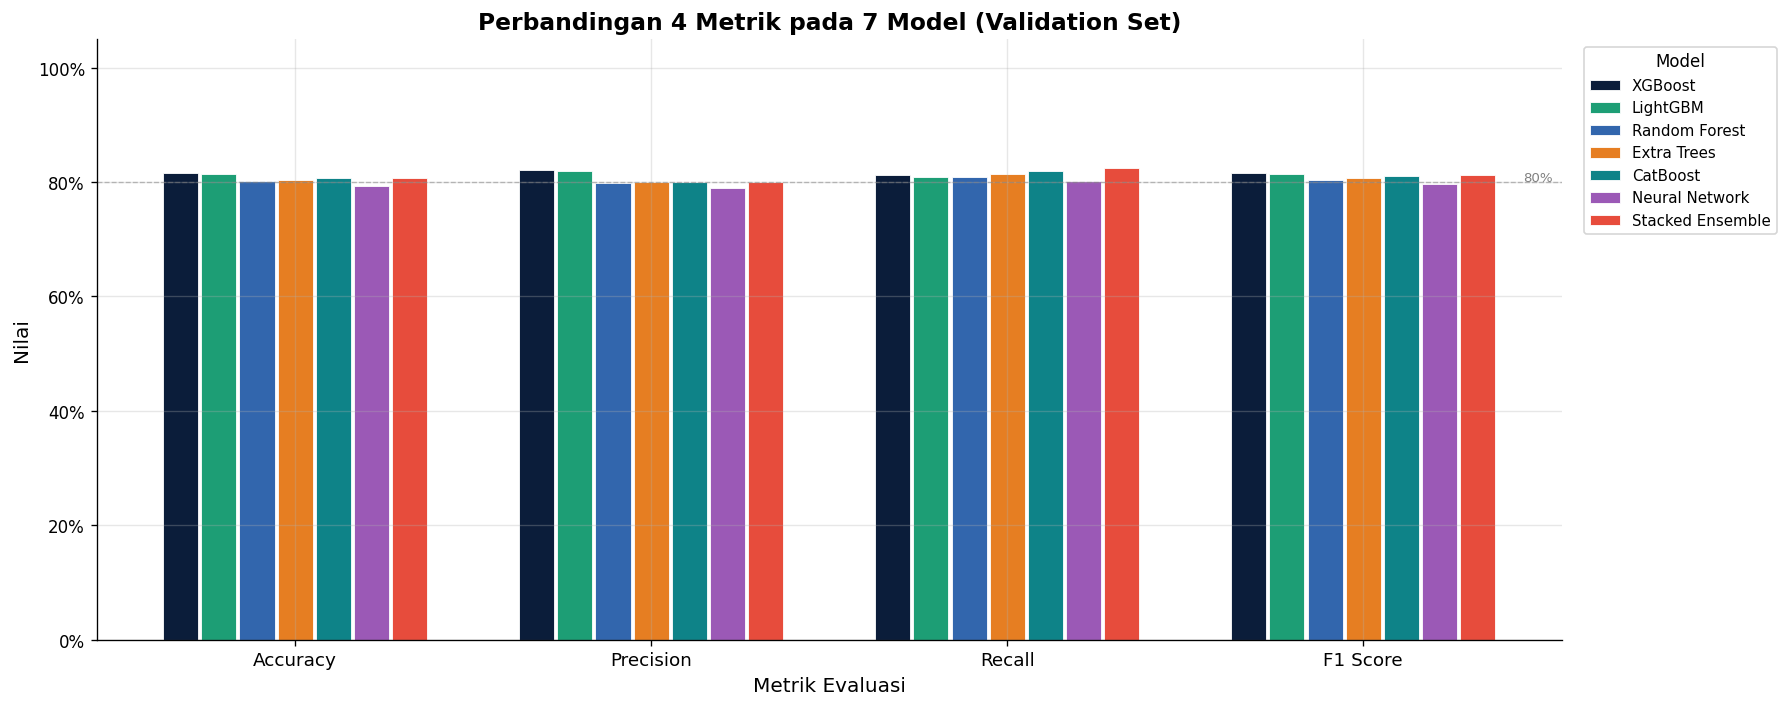

Bar chart perbandingan metrik tersimpan sebagai metrics_comparison.png


In [ ]:
MODEL_NAMES = [
    'XGBoost', 'LightGBM', 'Random Forest',
    'Extra Trees', 'CatBoost', 'Neural Network', 'Stacked Ensemble'
]
METRIC_NAMES = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
MODEL_COLORS = [
    '#0B1D3A', '#1d9e75', '#3266ad', '#e67e22',
    '#0e8388', '#9b59b6', '#e74c3c'
]

data = np.array([[results[m][met] for met in METRIC_NAMES] for m in MODEL_NAMES])

x      = np.arange(len(METRIC_NAMES))
n      = len(MODEL_NAMES)
width  = 0.75 / n

fig, ax = plt.subplots(figsize=(15, 6))

for i, (name, color) in enumerate(zip(MODEL_NAMES, MODEL_COLORS)):
    offset = (i - n / 2 + 0.5) * width
    bars   = ax.bar(x + offset, data[i], width * 0.92,
                    label=name, color=color, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('Perbandingan 4 Metrik pada 7 Model (Validation Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(
    title='Model', bbox_to_anchor=(1.01, 1), loc='upper left',
    fontsize=9, title_fontsize=10
)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(x[-1] + 0.45, 0.802, '80%', color='gray', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Bar chart perbandingan metrik tersimpan sebagai metrics_comparison.png')

## 10. Pembuatan File Submission

Setelah evaluasi selesai, setiap model dilatih ulang pada keseluruhan data pelatihan yang tersedia, bukan hanya pada subset 80 persen yang digunakan sebelumnya. Hal ini dilakukan untuk memaksimalkan informasi yang digunakan oleh setiap model sebelum memprediksi data test.

Setiap model menghasilkan satu file submission tersendiri dengan nama yang mencerminkan identitas model. File-file ini dapat disubmit satu per satu ke Kaggle untuk memperoleh public score dari masing-masing model, yang kemudian akan dibandingkan pada tahap berikutnya.

In [ ]:
print('Melatih ulang semua model pada keseluruhan data train...')

# Latih ulang 5 model pohon
final_models = {}
for name, model in TREE_MODELS.items():
    model.fit(X_all, y_all)
    final_models[name] = model
    print(f'  {name}: selesai')

# Latih ulang Neural Network
final_nn_model = train_nn(
    scaler.fit_transform(X_all).astype(np.float32),
    y_all.values, N_FEATURES
)
print('  Neural Network: selesai')

# OOF untuk meta-learner pada full data
oof_all = np.zeros((len(X_all), len(TREE_MODELS)))
for j, (name, model) in enumerate(TREE_MODELS.items()):
    oof = cross_val_predict(
        model.__class__(**model.get_params()),
        X_all, y_all, cv=SKF, method='predict_proba', n_jobs=-1
    )[:, 1]
    oof_all[:, j] = oof

final_meta = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
final_meta.fit(oof_all, y_all)
print('  Stacked Ensemble meta-learner: selesai')

Melatih ulang semua model pada keseluruhan data train...
  XGBoost: selesai
  LightGBM: selesai
  Random Forest: selesai
  Extra Trees: selesai
  CatBoost: selesai
  Neural Network: selesai
  Stacked Ensemble meta-learner: selesai


In [ ]:
def save_submission(pred_arr, filename):
    sub = pd.DataFrame({
        'PassengerId': test_ids,
        'Transported': pred_arr.astype(bool)
    })
    sub['Transported'] = sub['Transported'].map({True: 'True', False: 'False'})
    sub.to_csv(filename, index=False)
    print(f'  Tersimpan: {filename}  '
          f'(True: {sub["Transported"].eq("True").sum()}, '
          f'False: {sub["Transported"].eq("False").sum()})')

submission_filenames = {
    'XGBoost'        : 'submission_xgboost.csv',
    'LightGBM'       : 'submission_lightgbm.csv',
    'Random Forest'  : 'submission_randomforest.csv',
    'Extra Trees'    : 'submission_extratrees.csv',
    'CatBoost'       : 'submission_catboost.csv',
    'Neural Network' : 'submission_neuralnetwork.csv',
    'Stacked Ensemble': 'submission_stacked_ensemble.csv',
}

print('Membuat file submission...')

# 5 model pohon
for name, fname in list(submission_filenames.items())[:5]:
    pred = final_models[name].predict(X_test_proc)
    save_submission(pred, fname)

# Neural Network
pred_nn_test, _ = predict_nn(final_nn_model, X_test_sc)
save_submission(pred_nn_test, submission_filenames['Neural Network'])

# Stacked Ensemble
test_stack = np.column_stack([
    final_models[name].predict_proba(X_test_proc)[:, 1]
    for name in TREE_MODELS
])
pred_stack_test = final_meta.predict(test_stack)
save_submission(pred_stack_test, submission_filenames['Stacked Ensemble'])

print('\nSemua file submission berhasil dibuat.')

Membuat file submission...
  Tersimpan: submission_xgboost.csv  (True: 2165, False: 2112)
  Tersimpan: submission_lightgbm.csv  (True: 2186, False: 2091)
  Tersimpan: submission_randomforest.csv  (True: 2188, False: 2089)
  Tersimpan: submission_extratrees.csv  (True: 2196, False: 2081)
  Tersimpan: submission_catboost.csv  (True: 2223, False: 2054)
  Tersimpan: submission_neuralnetwork.csv  (True: 2088, False: 2189)
  Tersimpan: submission_stacked_ensemble.csv  (True: 2246, False: 2031)

Semua file submission berhasil dibuat.


## 11. Perbandingan Akurasi Hasil Submission Kaggle

Setelah ketujuh file submission disubmit ke Kaggle, nilai public score dari masing-masing model ditulis ke dalam dictionary di bawah ini. Public score mencerminkan akurasi model pada data test sesungguhnya yang tidak pernah dilihat oleh model selama pelatihan.

Perbandingan ini melengkapi evaluasi pada validation set dan dapat mengungkap apakah ada model yang overfit terhadap data train, yang ditandai dengan selisih besar antara validation accuracy dan Kaggle public score.

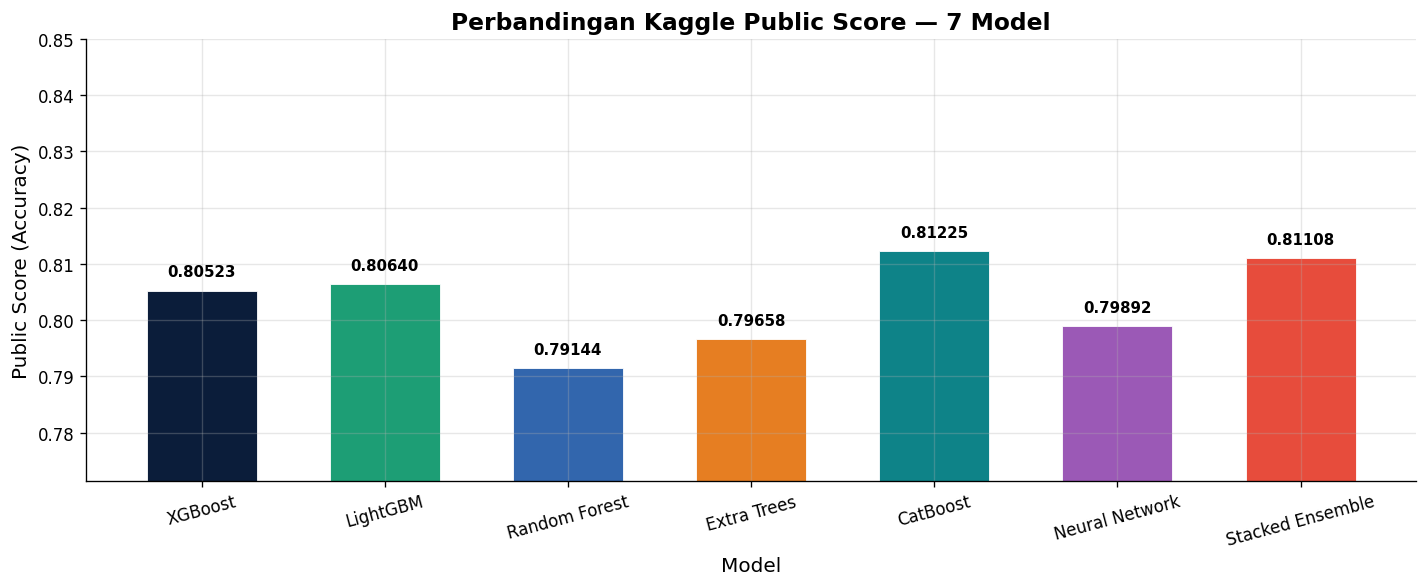

Bar chart Kaggle score tersimpan sebagai kaggle_score_comparison.png


In [ ]:
# Isi nilai public score dari Kaggle setelah melakukan submission
kaggle_scores = {
    'XGBoost'         : 0.80523,
    'LightGBM'        : 0.80640,
    'Random Forest'   : 0.79144,
    'Extra Trees'     : 0.79658,
    'CatBoost'        : 0.81225,
    'Neural Network'  : 0.79892,
    'Stacked Ensemble': 0.81108,
}

# Bar chart perbandingan Kaggle score
names  = list(kaggle_scores.keys())
scores = list(kaggle_scores.values())

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, scores, color=MODEL_COLORS, edgecolor='white', linewidth=0.5, width=0.6)

for bar, val in zip(bars, scores):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.5f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Public Score (Accuracy)', fontsize=12)
ax.set_title('Perbandingan Kaggle Public Score — 7 Model', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
y_min = max(0, min([s for s in scores if s > 0], default=0.7) - 0.02)
ax.set_ylim(y_min if y_min > 0 else 0, 0.85)

plt.tight_layout()
plt.savefig('kaggle_score_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print('Bar chart Kaggle score tersimpan sebagai kaggle_score_comparison.png')

## 12. Analisis Perbandingan Akhir

Sel ini menampilkan tabel ringkasan yang menggabungkan metrik dari validation set dengan public score Kaggle untuk setiap model. Perbandingan ini memberikan gambaran menyeluruh tentang performa setiap model. Apakah model yang baik pada validation set juga konsisten pada test set nyata, atau ada perbedaan yang menunjukkan overfitting.

In [ ]:
summary = pd.DataFrame(results).T.round(4)
summary.columns = ['Accuracy (Val)', 'Precision (Val)', 'Recall (Val)', 'F1 Score (Val)']
summary['Public Score (Kaggle)'] = pd.Series(kaggle_scores).round(5)
summary = summary.sort_values('Accuracy (Val)', ascending=False)

print('=== Ringkasan Perbandingan 7 Model ===')
print(summary.to_string())

best_val    = summary['Accuracy (Val)'].idxmax()
best_kaggle = summary['Public Score (Kaggle)'].idxmax()

print(f'\nModel terbaik pada validation set : {best_val}')
print(f'Model terbaik pada Kaggle test set : {best_kaggle}')

=== Ringkasan Perbandingan 7 Model ===
                  Accuracy (Val)  Precision (Val)  Recall (Val)  F1 Score (Val)  Public Score (Kaggle)
XGBoost                   0.8160           0.8210        0.8116          0.8163                0.80523
LightGBM                  0.8137           0.8187        0.8094          0.8140                0.80640
Stacked Ensemble          0.8074           0.7996        0.8242          0.8117                0.81108
CatBoost                  0.8062           0.8004        0.8196          0.8099                0.81225
Extra Trees               0.8033           0.7993        0.8139          0.8066                0.79658
Random Forest             0.8010           0.7991        0.8082          0.8036                0.79144
Neural Network            0.7924           0.7890        0.8025          0.7957                0.79892

Model terbaik pada validation set : XGBoost
Model terbaik pada Kaggle test set : CatBoost
